In [36]:
import os 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

from pathlib import Path 

ROOT = Path.cwd().parents[1] 
EMBED_PATH = ROOT / "data/embeddings/base_embeds.pt" 
EMBED_NAME = EMBED_PATH.stem 

IMAGE_DIR = ROOT / "images/stats" / EMBED_NAME 
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [37]:
os.makedirs(IMAGE_DIR, exist_ok=True)

In [38]:
mal_aurocs = pd.read_csv(RESULTS_DIR / "aurocs.csv", index_col=0)["mal_aurocs"] 

cls_cluster = pd.read_csv(RESULTS_DIR / "cluster_results.csv", index_col=0) 
patch_cluster = pd.read_csv(RESULTS_DIR / "patch_embed_summary.csv", index_col=0)

In [39]:
combined = cls_cluster.join(mal_aurocs) 

combined

,silhouette,good_inter,defect_inter,separation,good_intra,defect_intra,mal_aurocs
category,,,,,,,
bottle,0.104942,7.315164,18.281246,2.499089,6.936717,13.918730,1.000000
cable,0.005631,17.824219,22.918425,1.285802,17.336464,22.108633,0.945465
capsule,-0.072153,8.865550,13.054921,1.472545,8.762616,12.570441,0.940566
carpet,0.042476,10.594270,19.784689,1.867490,8.606181,16.614160,0.979535
grid,0.075255,19.194641,22.477030,1.171005,18.273792,19.301456,0.983292
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,0.948929
leather,0.161544,11.415674,26.463194,2.318145,9.138710,17.966808,1.000000
metal_nut,0.008135,12.177722,15.678962,1.287512,11.461521,14.659186,0.982893
pill,-0.054110,11.466780,15.724665,1.371323,11.294194,15.098664,0.950355


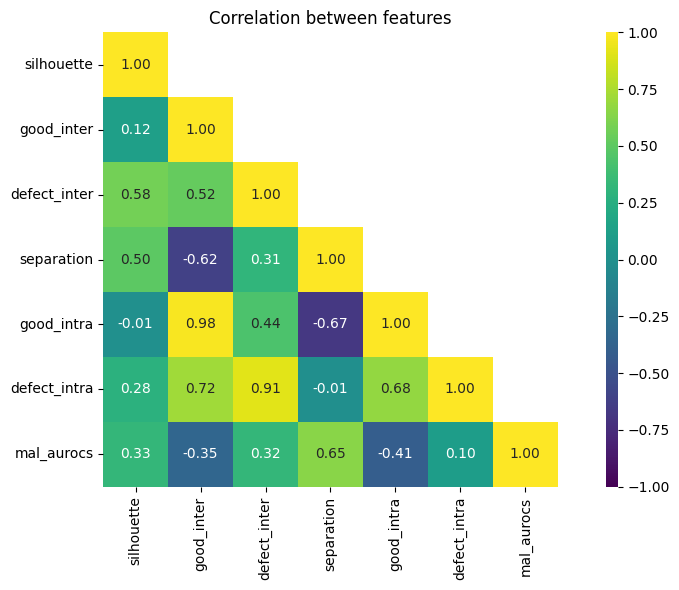

In [40]:
cor_cof = combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_corr.png")
plt.show()

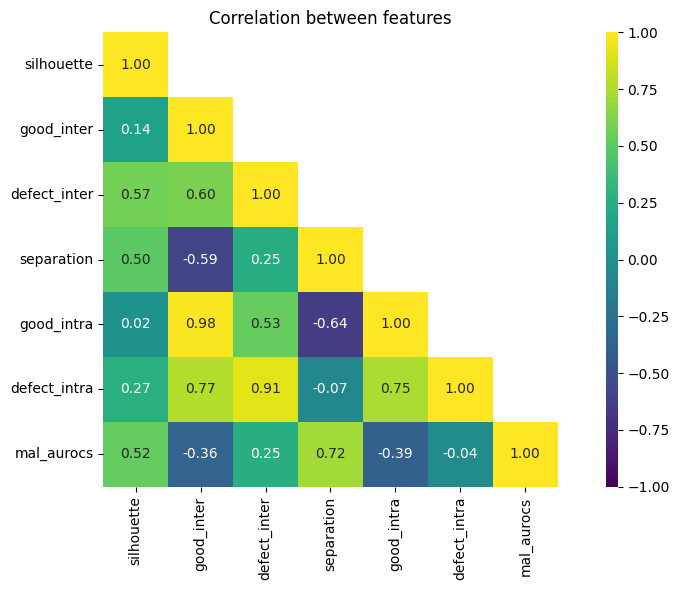

In [41]:
cor_cof = combined[combined.index != "screw"].corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_no_screw_corr.png")
plt.show()

In [42]:
fig = px.scatter( combined.reset_index(), x="separation", y="mal_aurocs", text="category", hover_name="category", trendline="ols" ) 
fig.data[1].line.color = "red"
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "cls_mal_sep_plot.svg")

In [43]:
patch_combined = patch_cluster.join(mal_aurocs) 

patch_combined

,silhouette,good_inter,defect_inter,separation,good_intra,defect_intra,intra_ratio,mal_aurocs
category,,,,,,,,
bottle,0.1032,35.5670,38.7166,1.0888,33.8505,24.6126,0.9763,1.000000
cable,0.1234,36.3120,42.2481,1.1644,34.2263,27.7112,0.9568,0.945465
capsule,0.1103,37.6490,45.1315,1.1989,37.0514,20.1856,0.9900,0.940566
carpet,0.2666,28.0213,44.2434,1.5799,24.8757,15.8434,0.9838,0.979535
grid,0.2727,29.8463,44.9653,1.5073,24.6649,16.2601,0.8976,0.983292
hazelnut,0.1479,39.1841,47.6354,1.2157,37.6479,23.3493,0.9669,0.948929
leather,0.2748,30.8956,49.6409,1.6115,26.4941,12.5874,1.0831,1.000000
metal_nut,0.0924,37.5273,37.4852,0.9997,34.3597,25.8242,0.9400,0.982893
pill,0.0977,37.9695,42.7971,1.1274,36.5540,23.9242,0.9674,0.950355


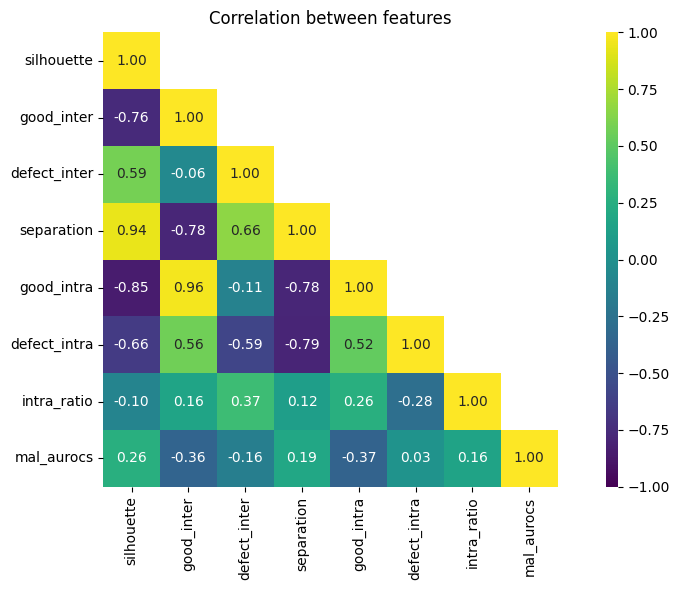

In [44]:
cor_cof = patch_combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_corr.png")
plt.show()

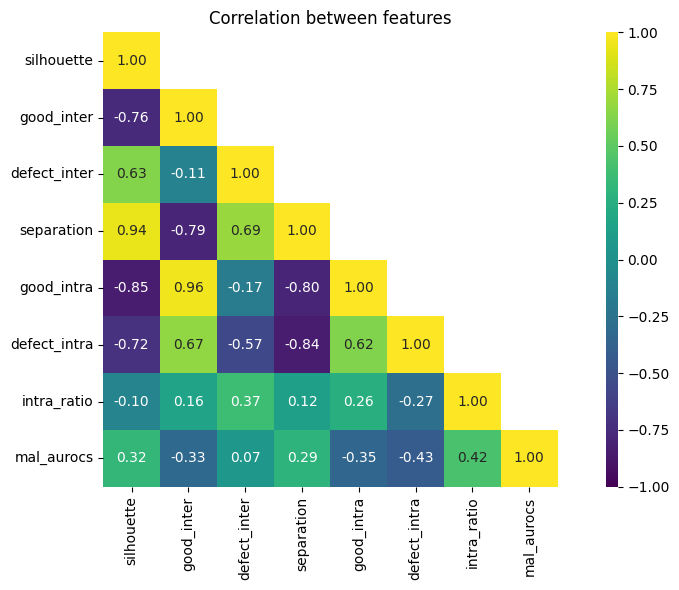

In [45]:
cor_cof = patch_combined[combined.index != "screw"].corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_no_screw_corr.png")
plt.show()

In [46]:
fig = px.scatter(patch_combined.reset_index(), x="defect_intra", y="mal_aurocs", text="category", hover_name="category", trendline="ols" ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "patch_mal_def_intra.svg")

In [47]:
cls_pref = cls_cluster.add_prefix("cls_")
patch_pref = patch_cluster.add_prefix("patch_")

combined = cls_pref.join(patch_pref)
combined = combined.join(mal_aurocs)

combined

,cls_silhouette,cls_good_inter,cls_defect_inter,cls_separation,cls_good_intra,cls_defect_intra,patch_silhouette,patch_good_inter,patch_defect_inter,patch_separation,patch_good_intra,patch_defect_intra,patch_intra_ratio,mal_aurocs
category,,,,,,,,,,,,,,
bottle,0.104942,7.315164,18.281246,2.499089,6.936717,13.918730,0.1032,35.5670,38.7166,1.0888,33.8505,24.6126,0.9763,1.000000
cable,0.005631,17.824219,22.918425,1.285802,17.336464,22.108633,0.1234,36.3120,42.2481,1.1644,34.2263,27.7112,0.9568,0.945465
capsule,-0.072153,8.865550,13.054921,1.472545,8.762616,12.570441,0.1103,37.6490,45.1315,1.1989,37.0514,20.1856,0.9900,0.940566
carpet,0.042476,10.594270,19.784689,1.867490,8.606181,16.614160,0.2666,28.0213,44.2434,1.5799,24.8757,15.8434,0.9838,0.979535
grid,0.075255,19.194641,22.477030,1.171005,18.273792,19.301456,0.2727,29.8463,44.9653,1.5073,24.6649,16.2601,0.8976,0.983292
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,0.1479,39.1841,47.6354,1.2157,37.6479,23.3493,0.9669,0.948929
leather,0.161544,11.415674,26.463194,2.318145,9.138710,17.966808,0.2748,30.8956,49.6409,1.6115,26.4941,12.5874,1.0831,1.000000
metal_nut,0.008135,12.177722,15.678962,1.287512,11.461521,14.659186,0.0924,37.5273,37.4852,0.9997,34.3597,25.8242,0.9400,0.982893
pill,-0.054110,11.466780,15.724665,1.371323,11.294194,15.098664,0.0977,37.9695,42.7971,1.1274,36.5540,23.9242,0.9674,0.950355


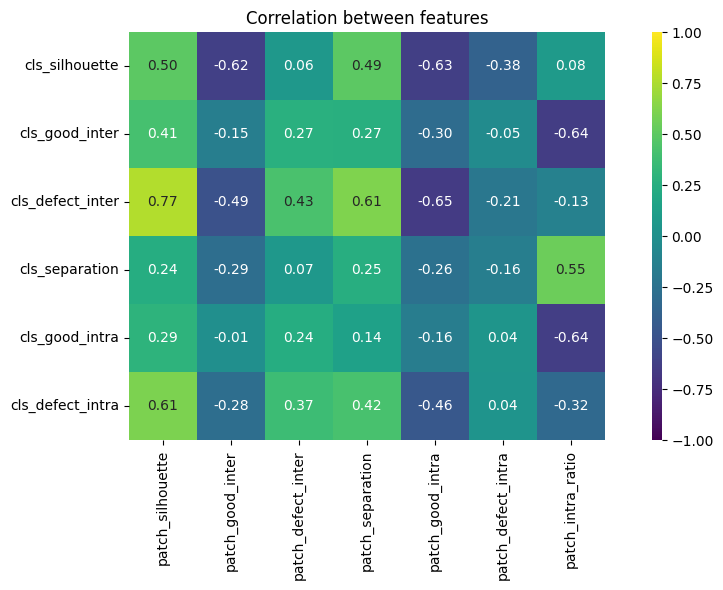

In [48]:
cls_cols = [c for c in combined.columns if c.startswith("cls_")]
patch_cols = [c for c in combined.columns if c.startswith("patch_")]

cor_cof = combined.corr() 
cor_cof = cor_cof.loc[cls_cols, patch_cols] 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.index, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_patch_corr.png")
plt.show()

In [49]:
fig = px.scatter(combined.reset_index(), x="patch_silhouette", y="cls_defect_inter", text="category", hover_name="category", trendline="ols", color="mal_aurocs", color_continuous_scale="Viridis") 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "cls_def_inter_patch_sil.svg")

In [50]:
fig = px.scatter(combined.reset_index(), x="patch_intra_ratio", y="cls_separation", text="category", hover_name="category", trendline="ols", color="mal_aurocs", color_continuous_scale="Viridis" ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 
fig.write_image(IMAGE_DIR / "cls_sep_patch_intra_ratio.svg")

In [51]:
fig = px.scatter(combined.reset_index(), x="patch_silhouette", y="cls_silhouette", text="category", hover_name="category", trendline="ols", color="mal_aurocs", color_continuous_scale="Viridis" ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "cls_sil_patch_sil.svg")